In [3]:
import pandas as pd
import numpy as np
import os, sys
import matplotlib.pyplot as plt

In [4]:
#rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny

path = "./data/newyorker_caption_contest/data/"
dirs = os.listdir(path)
files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i))]


df = pd.DataFrame()

for file in files:
    
    data = pd.read_csv(file, sep=',')
    data['contest_id'] = os.path.split(file)[-1]
    df = pd.concat([df, data])

df['contest_id'] = df['contest_id'].str.replace('.csv', '')  # Remove '.csv' from values
df.info()
print(data.head())

<class 'pandas.core.frame.DataFrame'>
Index: 2292678 entries, 0 to 4957
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   rank            float64
 1   caption         object 
 2   mean            float64
 3   precision       float64
 4   votes           int64  
 5   not_funny       int64  
 6   somewhat_funny  int64  
 7   funny           int64  
 8   contest_id      object 
dtypes: float64(3), int64(4), object(2)
memory usage: 174.9+ MB
                                             caption      mean  precision  \
0  Do you think death rays would be considered el...  1.632287   0.012004   
1                    Oh sure, now you look at a map.  1.632171   0.018294   
2                I've never heard of planet fitness.  1.626694   0.017874   
3  Wait, was it "conquer the mall" or "conquer th...  1.624266   0.020087   
4                          To Bed, Bath, and Beyond!  1.620504   0.013953   

   votes  not_funny  somewhat_funny  funny contest

In [ ]:
###OLD--->not used anymore
# Assuming 'df' is your DataFrame
df_filtered = df[df['contest_id'] == "510"]

# Creating the scatter plot
df_filtered.plot(kind='scatter', x='rank', y='votes', title='Votes vs. Rank', xlabel='Rank', ylabel='Votes')

# Show the plot
plt.show()


###next cell
# Scatter plot for "not funny" votes
plt.scatter(df_filtered['rank'], df_filtered['not_funny'], color='red', label='Not Funny', alpha=0.6)

# Scatter plot for "funny" votes
plt.scatter(df_filtered['rank'], df_filtered['funny'], color='blue', label='Funny', alpha=0.6)


# Adding titles and labels
plt.title('Funny vs. Not Funny Votes by Rank')
plt.xlabel('Rank')
plt.ylabel('Votes')
plt.legend()  # Show legend
plt.grid(True)  # Optional: Adding grid for better readability
plt.show()

In [ ]:
###OLD code--->not used anymore

women_count = df['caption'].str.contains('women').sum()

#print(df_filtered['caption'].str.contains('women').sum())

men_count = df['caption'].str.contains('men').sum() - women_count

dino_count = df['caption'].str.contains('dino').sum()

witch_count = df['caption'].str.contains('witch').sum()


fig, ax = plt.subplots()

words = ['women',  'dino', 'witch'] #had to remove men, cause its so much more
counts = [women_count, dino_count, witch_count]


ax.bar(words, counts)

ax.set_ylabel('mentioned')
ax.set_title('Who')


plt.show()



### Yunos part

note for downstream work:
add sir to men wordlist and search the top words for more relevant words

then we can say, that we deciedet to do the wordlist for relevant words in the top 100 most frequent...


@jannik first of all load Silvias combined data

C:\Users\janni\AppData\Local\Temp\ipykernel_21784\4238554609.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_captions = df.groupby('contest_id', group_keys=False).apply(


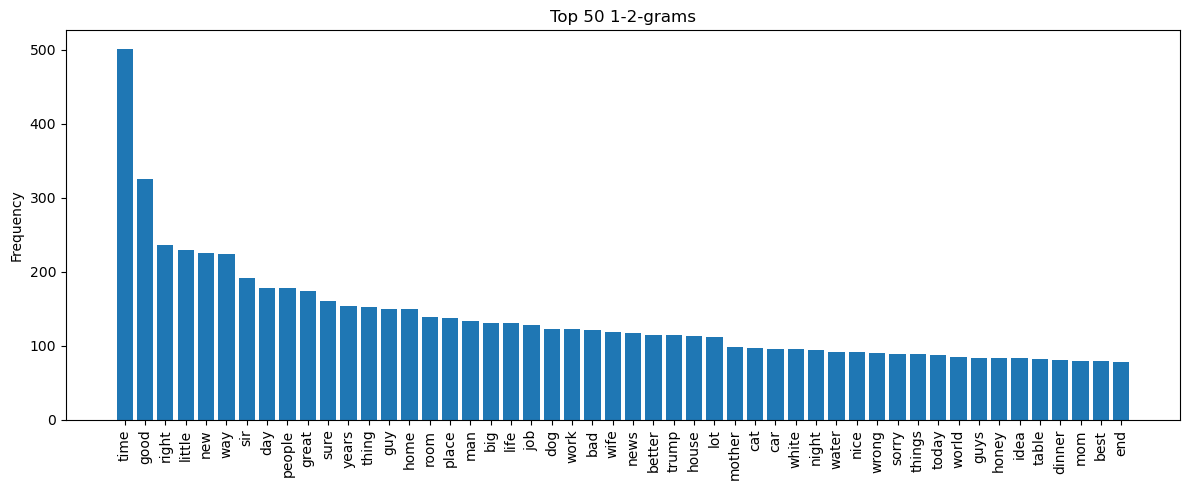

In [11]:
from src.utils.data_utils import count_terms, top_terms, plot_top_terms



top_captions = df.groupby('contest_id', group_keys=False).apply(
    lambda x: x.nlargest(50, 'votes'))
    
top_captions = top_captions['caption'].dropna().astype(str).tolist()




vocab, counts = count_terms(top_captions)
top_vocab, top_counts = top_terms(vocab, counts)
plot_top_terms(top_vocab, top_counts)


In [10]:
print((top_vocab))

['time' 'good' 'new' 'way' 'right' 'little' 'sir' 'day' 'people' 'sure'
 'great' 'thing' 'years' 'room' 'big' 'guy' 'life' 'home' 'job' 'man'
 'house' 'place' 'dog' 'trump' 'news' 'bad' 'better' 'work' 'wife' 'lot'
 'car' 'mother' 'sorry' 'cat' 'water' 'night' 'table' 'white' 'honey'
 'nice' 'today' 'best' 'wrong' 'idea' 'world' 'dinner' 'things' 'old'
 'free' 'mom']


### Filter for gender inequallities with words from previous analysis (and more)

In [13]:
#word list to filter for certain toipcs:
women_filter = "women|girl|mother|wife"  #words that imply a women appeared in the caption text (note: without pronouns cause we search explicit mentions)
men_filter = "men|boy|father|husband" #words that imply a men appear in the caption text (note: substract women_filter to avoid havind the cound for the word woMEN)
dino_filter = "dino|rex"
witch_filter = "witch|enchantress"



coutdict = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband|sir",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "trump": "trump|donald|president",
  "women_count": "women"
}

def do_counts(caption_array = df['caption'].copy(), who_count = {
  "house": "house"
}):
    #Count the words in all the captions of all the comics
    counted_dic = who_count.copy()
    counted = []
    for key, value in counted_dic.items():
        counted_dic[key] = (caption_array.str.contains(value).sum())
        counted.append(counted_dic[key])
    return counted
overall_counts = (do_counts(df['caption'].copy(), coutdict))


KeyboardInterrupt: 

In [36]:
coutdict = {
  "women_count": "women",
  "men": "men|boy|father|husband|sir", 
  "women": "women|girl|mother|wife",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "trump": "trump|donald|president"
  
}

###Analyse the mentions over time

#find all IDs:
ids = np.array(df['contest_id'].copy().drop_duplicates())
counts_per_contest = []

for i in range(len(ids)-1):
    df_ID = df[df['contest_id'] == str(ids[i])]
    counts_per_contest.append(do_counts(df_ID['caption'].copy(), coutdict))
counts_per_contest = np.array(counts_per_contest)
print(counts_per_contest)


[[  4 132  86   2   3  12]
 [  2 126 120   1  39   4]
 [  4 188  53   0   0   2]
 ...
 [  2 146  84  95   1   3]
 [  0 291 144   0   1   3]
 [  8 138  29   1   1  10]]


In [49]:
df_counts = pd.DataFrame(counts_per_contest, columns=["w", "Men", "Women", "Dino", "Witch", "Trump"])

df_counts["Men"] = df_counts["Men"]-df_counts["w"]
df_counts = df_counts.drop(["w"], axis=1)
df_counts.head(5)

,Men,Women,Dino,Witch,Trump
0,128,86,2,3,12
1,124,120,1,39,4
2,184,53,0,0,2
3,158,30,5,9,9
4,147,16,1,7,5


379


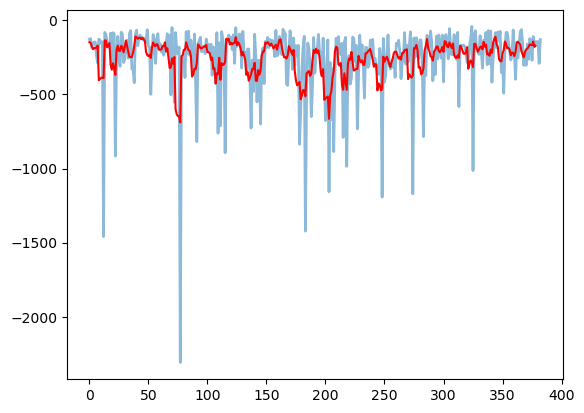

In [ ]:
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n


In [64]:
print(np.array(df_counts))

[[128  86   2   3  12]
 [124 120   1  39   4]
 [184  53   0   0   2]
 ...
 [144  84  95   1   3]
 [291 144   0   1   3]
 [130  29   1   1  10]]


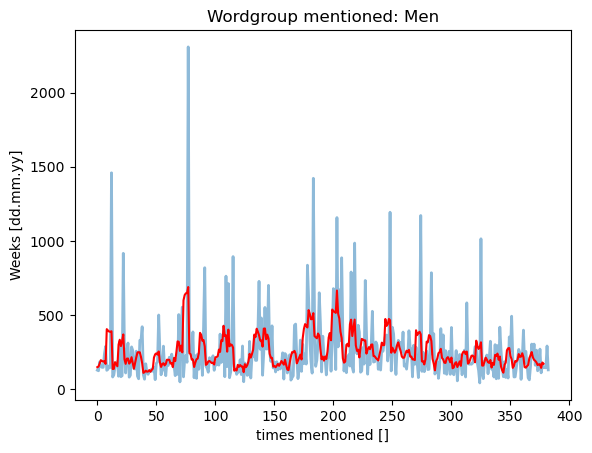

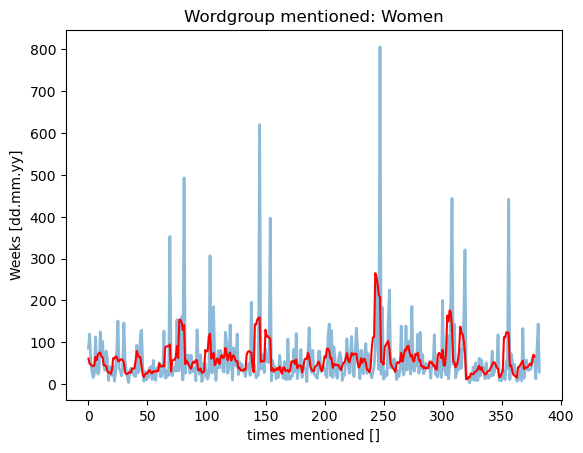

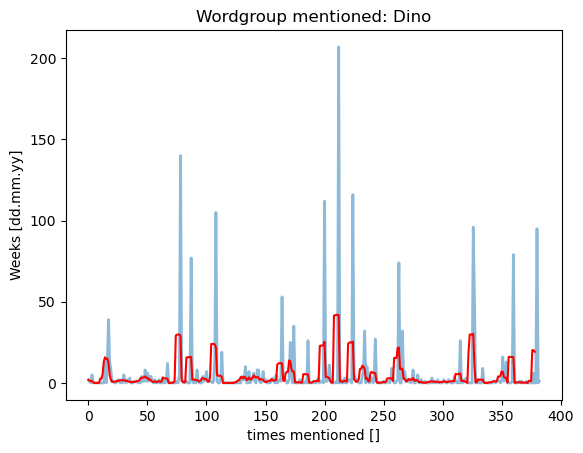

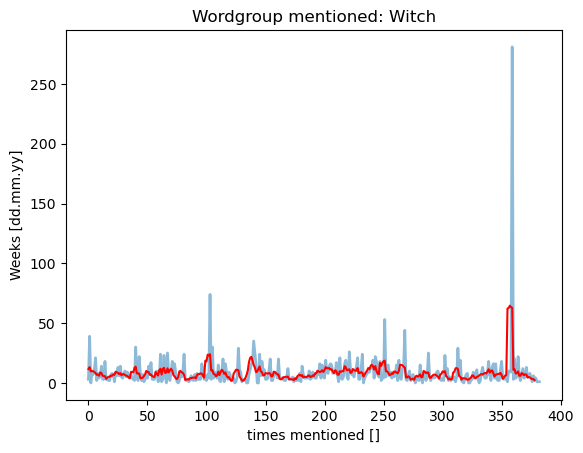

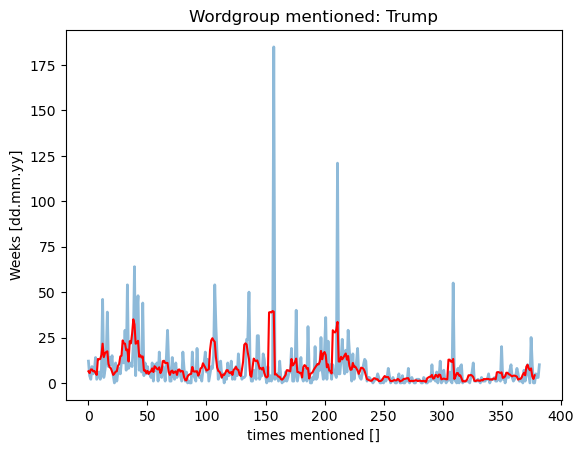

IndexError: index 5 is out of bounds for axis 1 with size 5

In [91]:
def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

c = np.array(df_counts)
words = ["Men", "Women", "Dino", "Witch", "Trump"]

for i in range(0,len(c[:,0])-1):
    Y1 = c[:,i]
    Y2 = moving_average(Y1, 5)
    plt.plot(np.arange(len(Y1)), Y1,linestyle='-', linewidth=2,alpha=.5)
    plt.plot(np.arange(len(Y2)), Y2,color='r')
    plt.title('Wordgroup mentioned: '+words[i])
    plt.ylabel('Weeks [dd.mm.yy]')
    plt.xlabel('times mentioned []')
    plt.show()

379


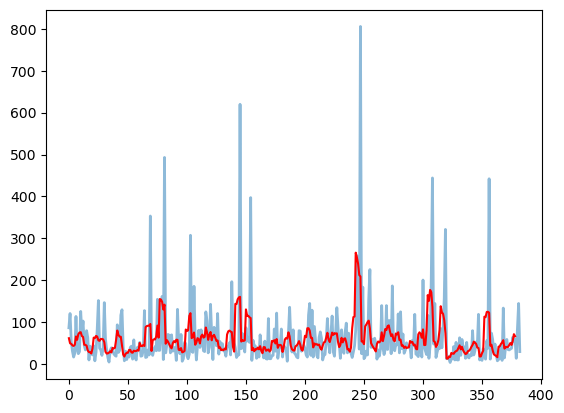

IndexError: index 5 is out of bounds for axis 1 with size 2

In [42]:

men_women_count = np.array(all_counts)


def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

Y11 = men_women_count[:,0]
Y12 = moving_average(Y11,5)
print(len(Y12))
time = np.arange(len(Y11))

plt.plot(np.arange(len(Y11)), Y11,linestyle='-', linewidth=2,alpha=.5)
plt.plot(np.arange(len(Y12)), Y12,color='r')

#plt.axhline(y=np.nanmean(men_women_count))

plt.show()

Y21 = men_women_count[:,1]- men_women_count[:,5]
Y22 = moving_average(Y11,5)
print(len(Y12))
time = np.arange(len(Y11))

plt.plot(np.arange(len(Y21)), Y21,linestyle='-', linewidth=2,alpha=.5)
plt.plot(np.arange(len(Y22)), Y22,color='r')

#plt.axhline(y=np.nanmean(men_women_count))

plt.show()

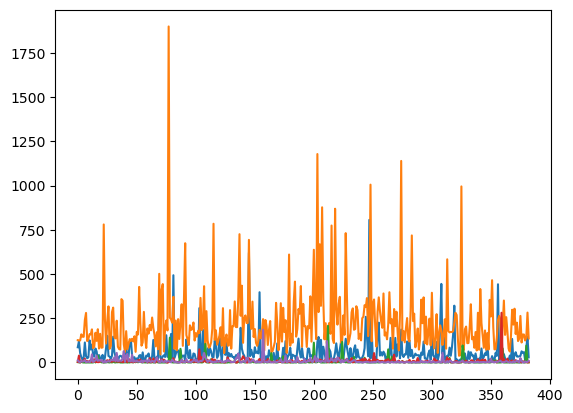

In [ ]:
plt.plot(all_counts)
#all

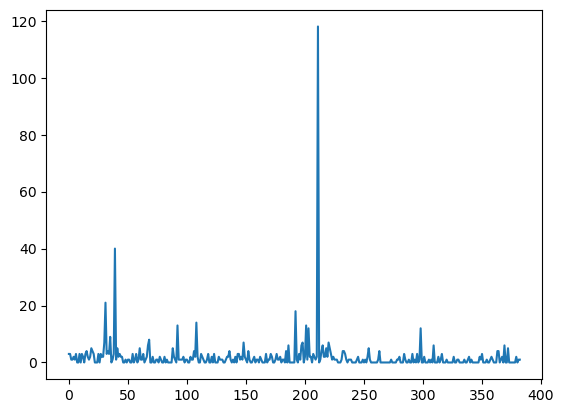

In [ ]:
plt.plot(all_counts)
#trump

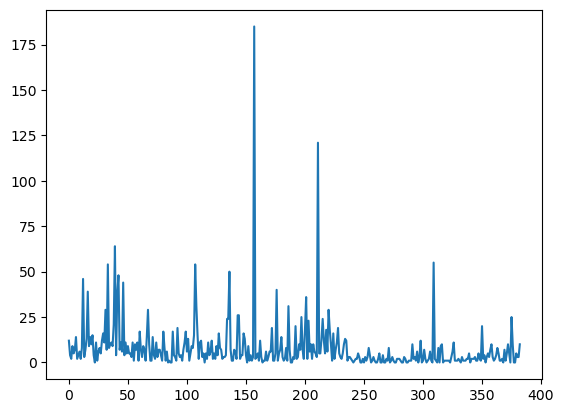

In [ ]:
plt.plot(all_counts)
#trump, president, donald

[22892, 86116, 1987]


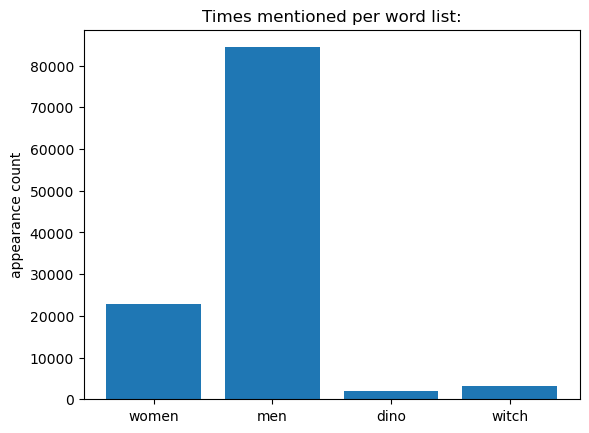

In [13]:
#plot the counts of the wordlist for all the data together as a boxplot
coutdict = {
  "women": "women|girl|mother|wife",
  "men": "men|boy|father|husband",
  "dino": "dino|rex",
  "witch": "witch|enchantress",
  "onlywomen": "women"
}

counts = do_counts(df['caption'].copy(), coutdict)



fig, ax = plt.subplots()

words = ['women',  'men', 'dino', 'witch'] #think about substracting women from men!!!!

print(counts[:3])
counts[1] = counts[1]- counts[4]
ax.bar(words, counts[:4])
ax.set_ylabel('appearance count')
ax.set_title('Times mentioned per word list:')

plt.show()